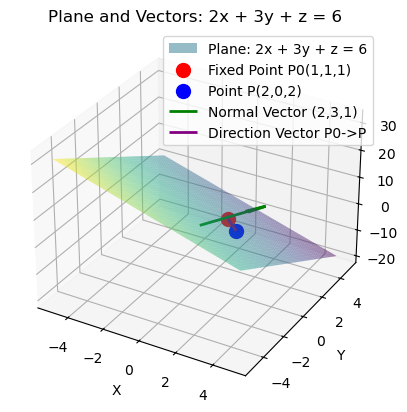

Dot product of normal vector and direction vector: 0


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from homemade.ensemble.ensemble import svc_clf

from notebooks.neural_network.multilayer_perceptron_fashion_demo import alpha

# 设置平面方程 2x + 3y + z - 6 = 0
A, B, C, D = 2, 3, 1, -6
normal_vector = np.array([A, B, C])

# 创建三维图形
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# 绘制平面
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = (-A * X - B * Y - D) / C  # 由平面方程解出 z

ax.plot_surface(X, Y, Z, alpha=0.5, cmap='viridis', label='Plane: 2x + 3y + z = 6')

# 固定点 P0 (选择一个平面上的点，例如 x=1, y=1 时，z=1)
x0, y0, z0 = 1, 1, 1
ax.scatter([x0], [y0], [z0], color='red', s=100, label='Fixed Point P0(1,1,1)')

# 平面上的另一点 P (例如 x=2, y=0, z=2)
x, y, z = 2, 0, 2
ax.scatter([x], [y], [z], color='blue', s=100, label='Point P(2,0,2)')

# 绘制法向量 (从原点开始，为了可视化调整长度)
ax.quiver(0, 0, 0, A, B, C, color='green', label='Normal Vector (2,3,1)', linewidth=2)

# 绘制从 P0 到 P 的方向向量
direction_vector = np.array([x - x0, y - y0, z - z0])
ax.quiver(x0, y0, z0, direction_vector[0], direction_vector[1], direction_vector[2],
          color='purple', label='Direction Vector P0->P', linewidth=2)

# 设置坐标轴标签
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# 设置图形标题
plt.title('Plane and Vectors: 2x + 3y + z = 6')

# 添加图例
ax.legend()

# 显示图形
plt.show()

# 验证点积
dot_product = np.dot(normal_vector, direction_vector)
print(f"Dot product of normal vector and direction vector: {dot_product}")

In [3]:
import numpy as np

class UnifiedSVM:
    def __init__(self, lr=0.001, epochs=1000, C=None, kernel=None, gamma=None):
        """
        C: 如果为 None，表示硬间隔 SVM；否则表示软间隔的惩罚系数。
        kernel: 一个可调用函数，接受两个数组 (x1, x2) 并返回它们的核相似度。
                如果为 None，默认为线性核（点积）。
        gamma: RBF 核函数的参数。如果核函数不是 RBF，则忽略。
        """
        self.lr = lr
        self.epochs = epochs
        self.C = C
        # 存储实际的核函数
        self.kernel_func = self._get_kernel_function(kernel, gamma)
        # 存储 gamma 以备后续使用或记录
        self.gamma = gamma

    def _get_kernel_function(self, kernel_name, gamma):
        # 获取具体的核函数实现
        if kernel_name is None or kernel_name == 'linear':
            return lambda x1, x2: np.dot(x1, x2)
        elif kernel_name == 'poly':
            # 多项式核示例: K(x, z) = (x.z + 1)^degree
            # 需要一个 'degree' 参数，目前不在 __init__ 中
            # 为简单起见，如果选择 poly 且未指定 degree，则假定 degree=2
            degree = 2 # 演示占位符
            return lambda x1, x2: (np.dot(x1, x2) + 1)**degree
        elif kernel_name == 'rbf':
            if gamma is None:
                raise ValueError("RBF 核函数必须指定 Gamma 值。")
            # RBF (高斯) 核函数: K(x, z) = exp(-gamma * ||x - z||^2)
            return lambda x1, x2: np.exp(-gamma * np.sum((x1 - x2)**2))
        else:
            raise ValueError(f"未知的核函数类型: {kernel_name}")

    def fit(self, X, y):
        n_samples, n_features = X.shape
        y_scaled = y.astype(np.float64) # 使用 float64 进行计算
        # 确保标签为 -1 和 1
        y_scaled[y_scaled == 0] = -1

        # 在核 SVM 中，我们优化的是拉格朗日乘子 alpha，而不是直接的 w。
        # w 是由 alpha 和支持向量隐式定义的。
        # 初始化 alpha 值（每个训练样本一个）
        self.alphas = np.zeros(n_samples)
        self.b = 0
        self.X_train = X # 存储训练数据用于核函数计算
        self.y_train = y_scaled # 存储训练标签

        # 预计算核矩阵 K
        # K_ij = kernel_func(X_i, X_j)
        self.K_matrix = np.zeros((n_samples, n_samples))
        for i in range(n_samples):
            for j in range(n_samples):
                self.K_matrix[i, j] = self.kernel_func(X[i], X[j])

        # 简化版的 alpha 梯度下降（并非真正的 SMO，但用于说明概念）
        # 这是一个高度简化的核 SVM 训练方法，可能不如专门的算法（如 SMO）收敛得好。
        for epoch in range(self.epochs):
            # 遍历每个 alpha_i
            for i in range(n_samples):
                # 计算当前决策函数对 X[i] 的输出
                # f(X[i]) = sum(alpha_j * y_j * K(X_j, X_i)) + b
                # 注意：这是 alpha 梯度下降更新的近似值。
                # 真正的对偶问题优化涉及更复杂的规则。

                # 计算当前样本的“误差”或“违规”
                # alpha_i 的梯度涉及对偶目标中的项。
                # 对于铰链损失，这与 (y_i * f(x_i) - 1) 相关

                # 当前样本的预测值
                # H_i = sum_j(alpha_j * y_j * K(X_j, X_i))
                H_i = np.sum(self.alphas * self.y_train * self.K_matrix[:, i]) + self.b

                # 误差项（与铰链损失的导数相关）
                error = y_scaled[i] * H_i

                # alpha_i 的更新规则（简化版）
                # 这是一个非常基本的梯度更新。
                # 对于硬间隔，alpha_i 仅在支持向量处 > 0。
                # 对于软间隔，alpha_i 的范围是 [0, C]。

                # 硬间隔 (C 为 None)：只在误分类时更新
                if self.C is None:
                    if error < 1: # 如果违反约束，增加 alpha_i
                        self.alphas[i] += self.lr * y_scaled[i] * (1 - error) # 基于 (1 - y_i * H_i) 的更新
                        # 将 alpha 裁剪为非负（概念上，这里不总是严格为正）
                        self.alphas[i] = max(0, self.alphas[i])
                # 软间隔 (C 不为 None)：使用铰链损失导数进行更新
                else:
                    if error < 1: # 如果违反约束（未达到间隔）
                        # 更新 alpha_i (这是简化的更新，实际 SMO 更复杂)
                        self.alphas[i] += self.lr * (y_scaled[i] * (1 - error))
                        # 将 alpha 裁剪在 0 和 C 之间
                        self.alphas[i] = np.clip(self.alphas[i], 0, self.C)
                    else: # 如果达到或超过间隔
                        # 对于铰链损失导数，alpha 不会直接基于误分类更新，但它是正则化项的一部分
                        # 这里我们仍然考虑 w 的正则化项，所以即使分类正确，w 相关的 alpha 也会有微小调整
                        self.alphas[i] -= self.lr * self.alphas[i] # 对应 0.5 * ||w||^2 的梯度
                        self.alphas[i] = np.clip(self.alphas[i], 0, self.C) # 确保仍在 [0, C] 范围内

        # 训练后，计算截距 b。
        # 计算 b 的常用方法是对不在间隔边界上的支持向量（0 < alpha_i < C）进行平均。
        # 这是计算核 SVM 的 b 值更稳定的方法。
        # 找到支持向量（alpha 大于一个很小的 epsilon）
        sv_indices = np.where(self.alphas > 1e-5)[0] # 非零 alpha 的阈值
        if len(sv_indices) > 0:
            b_values = []
            for i in sv_indices:
                # b = y_i - sum(alpha_j * y_j * K(X_j, X_i))
                predicted_val = np.sum(self.alphas * self.y_train * self.K_matrix[:, i])
                b_values.append(self.y_train[i] - predicted_val)
            self.b = np.mean(b_values) # 对支持向量的 b 值取平均
        else:
            self.b = 0 # 如果没有找到支持向量（对于良好的拟合不太可能）

    def predict(self, X):
        # 核 SVM 中的预测函数使用训练数据的核矩阵
        n_samples_test = X.shape[0]
        predictions = np.zeros(n_samples_test)

        for i in range(n_samples_test):
            # 为每个测试样本计算 K(X_train, X_test_i)
            kernel_values = np.zeros(self.X_train.shape[0])
            for j in range(self.X_train.shape[0]):
                kernel_values[j] = self.kernel_func(self.X_train[j], X[i])

            # 决策函数: sum(alpha_j * y_j * K(X_j, X_i)) + b
            predictions[i] = np.sum(self.alphas * self.y_train * kernel_values) + self.b

        return np.sign(predictions)

--- 线性核函数示例 ---
线性 SVM 准确度: 0.7333


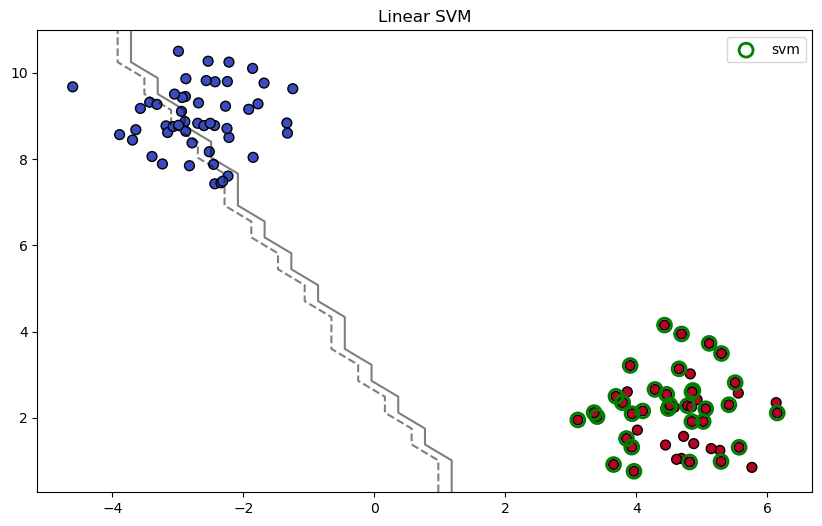


--- RBF 核函数示例 ---
RBF 核 SVM 准确度: 0.3333


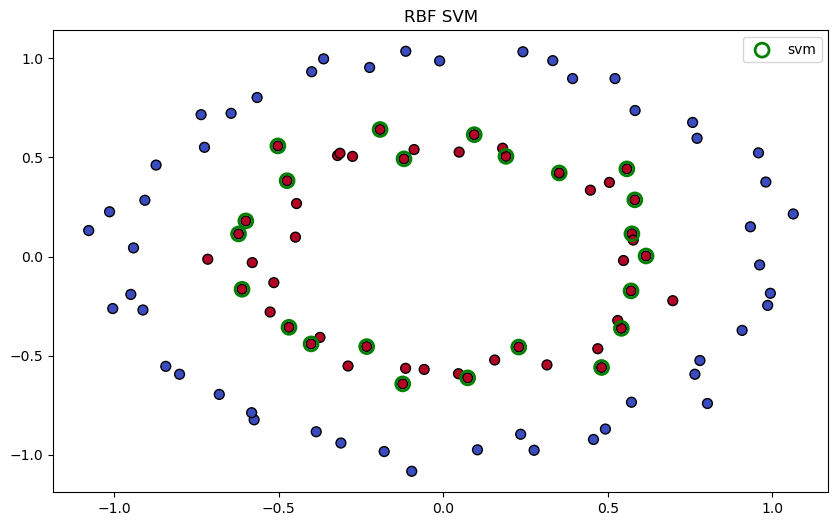


--- 多项式核函数示例 ---
多项式核 SVM 准确度: 0.2500


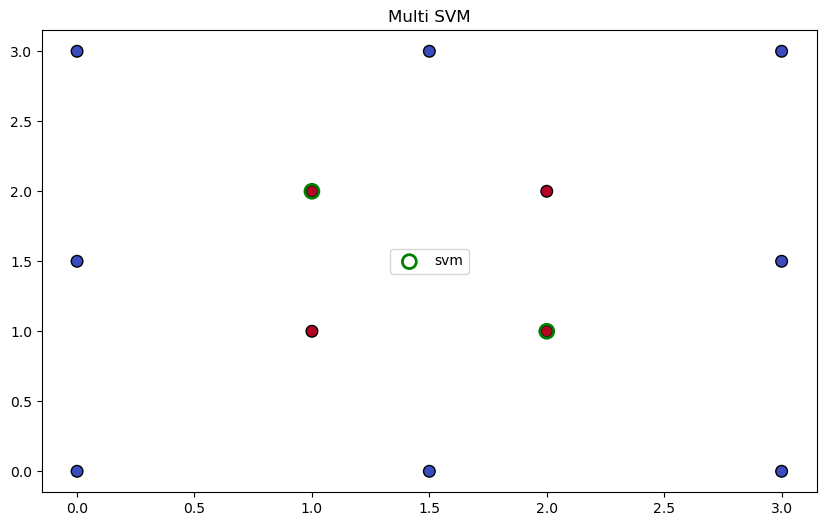

In [6]:
from sklearn.datasets import make_circles, make_blobs
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# --- 1. 线性核函数示例 ---
print("--- 线性核函数示例 ---")
X_linear, y_linear = make_blobs(n_samples=100, centers=2, random_state=42, cluster_std=0.8)
y_linear[y_linear == 0] = -1 # 确保标签为 -1 和 1

X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(X_linear, y_linear, test_size=0.3, random_state=42)

svm_linear = UnifiedSVM(lr=0.001, epochs=2000, C=1.0, kernel='linear')
svm_linear.fit(X_train_lin, y_train_lin)
predictions_lin = svm_linear.predict(X_test_lin)
accuracy_lin = np.mean(predictions_lin == y_test_lin)
print(f"线性 SVM 准确度: {accuracy_lin:.4f}")

# 绘制线性 SVM 结果
plt.figure(figsize=(10, 6))
plt.scatter(X_linear[:, 0], X_linear[:, 1], c=y_linear, cmap='coolwarm', s=50, edgecolors='k')
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# 创建网格以评估模型
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = svm_linear.predict(xy).reshape(XX.shape)

ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])
# 绘制支持向量（alpha 大于一个很小的阈值）
ax.scatter(svm_linear.X_train[svm_linear.alphas > 1e-5, 0], svm_linear.X_train[svm_linear.alphas > 1e-5, 1],
           s=100, facecolors='none', edgecolors='green', linewidths=2, label='svm')
plt.title('Linear SVM')
plt.legend()
plt.show()

# --- 2. RBF 核函数示例 (用于非线性可分数据) ---
print("\n--- RBF 核函数示例 ---")
X_rbf, y_rbf = make_circles(n_samples=100, factor=0.6, noise=0.05, random_state=42)
y_rbf[y_rbf == 0] = -1 # 确保标签为 -1 和 1

X_train_rbf, X_test_rbf, y_train_rbf, y_test_rbf = train_test_split(X_rbf, y_rbf, test_size=0.3, random_state=42)

# 对于这种简化的梯度方法，使用更大的学习率和更多的 epoch
svm_rbf = UnifiedSVM(lr=0.01, epochs=5000, C=1.0, kernel='rbf', gamma=15) # Gamma 对于 RBF 至关重要
svm_rbf.fit(X_train_rbf, y_train_rbf)
predictions_rbf = svm_rbf.predict(X_test_rbf)
accuracy_rbf = np.mean(predictions_rbf == y_test_rbf)
print(f"RBF 核 SVM 准确度: {accuracy_rbf:.4f}")

# 绘制 RBF SVM 结果
plt.figure(figsize=(10, 6))
plt.scatter(X_rbf[:, 0], X_rbf[:, 1], c=y_rbf, cmap='coolwarm', s=50, edgecolors='k')
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# 创建网格以评估模型
xx = np.linspace(xlim[0], xlim[1], 50)
yy = np.linspace(ylim[0], ylim[1], 50)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = svm_rbf.predict(xy).reshape(XX.shape)

ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])
ax.scatter(svm_rbf.X_train[svm_rbf.alphas > 1e-5, 0], svm_rbf.X_train[svm_rbf.alphas > 1e-5, 1],
           s=100, facecolors='none', edgecolors='green', linewidths=2, label='svm')
plt.title('RBF SVM')
plt.legend()
plt.show()

# --- 3. 多项式核函数示例 ---
print("\n--- 多项式核函数示例 ---")
# 让我们使用一个多项式核可能表现更好的稍微复杂的数据集
X_poly = np.array([
    [1, 1], [1, 2], [2, 1], [2, 2], # 类别 1（在一个“正方形”内部）
    [0, 0], [0, 3], [3, 0], [3, 3], # 类别 -1（在外部）
    [1.5, 0], [0, 1.5], [1.5, 3], [3, 1.5] # 更多的类别 -1，使其非线性
])
y_poly = np.array([1, 1, 1, 1, -1, -1, -1, -1, -1, -1, -1, -1])

X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_poly, y_poly, test_size=0.3, random_state=42)

svm_poly = UnifiedSVM(lr=0.01, epochs=5000, C=1.0, kernel='poly') # 默认为 degree=2
svm_poly.fit(X_train_poly, y_train_poly)
predictions_poly = svm_poly.predict(X_test_poly)
accuracy_poly = np.mean(predictions_poly == y_test_poly)
print(f"多项式核 SVM 准确度: {accuracy_poly:.4f}")

# 绘制多项式 SVM 结果
plt.figure(figsize=(10, 6))
plt.scatter(X_poly[:, 0], X_poly[:, 1], c=y_poly, cmap='coolwarm', s=70, edgecolors='k')
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# 创建网格以评估模型
xx = np.linspace(xlim[0], xlim[1], 50)
yy = np.linspace(ylim[0], ylim[1], 50)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = svm_poly.predict(xy).reshape(XX.shape)

ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])
ax.scatter(svm_poly.X_train[svm_poly.alphas > 1e-5, 0], svm_poly.X_train[svm_poly.alphas > 1e-5, 1],
           s=100, facecolors='none', edgecolors='green', linewidths=2, label='svm')
plt.title('Multi SVM')
plt.legend()
plt.show()

In [7]:
import numpy as np

class UnifiedSVM:
    def __init__(self, lr=0.001, epochs=1000, C=None):
        """
        C: 如果为 None，表示硬间隔 SVM；否则表示软间隔的惩罚系数
        """
        self.lr = lr
        self.epochs = epochs
        self.C = C  # 如果为 None，则为硬间隔

    def fit(self, X, y):
        n_samples, n_features = X.shape
        y = y.astype(np.float64)
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.epochs):
            for i in range(n_samples):
                condition = y[i] * (np.dot(X[i], self.w) + self.b)

                # 区分软硬间隔
                if self.C is None:
                    # 硬间隔：只处理误分类点（condition < 1）
                    if condition < 1:
                        ## dw和db都是根据condition求导的梯度负方向
                        dw = -y[i] * X[i]
                        db = -y[i]
                        self.w -= self.lr * dw
                        self.b -= self.lr * db
                else:
                    # 软间隔：有惩罚项 + hinge loss
                    if condition >= 1:
                        dw = self.w
                        db = 0
                    else:
                        dw = self.w - self.C * y[i] * X[i]
                        db = -self.C * y[i]

                    self.w -= self.lr * dw
                    self.b -= self.lr * db

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)


In [8]:
X = np.array([
    [2, 3],
    [3, 4],
    [4, 3],
    [5, 5],
    [1, 0],
    [0, 1],
    [1, 1]
])
y = np.array([1, 1, 1, 1, -1, -1, -1])

# 软间隔 SVM（有容错）
model_soft = UnifiedSVM(lr=0.01, epochs=10000, C=1.0)
model_soft.fit(X, y)
print("Soft SVM:", model_soft.w, model_soft.b)

# 硬间隔 SVM（不容错）
model_hard = UnifiedSVM(lr=0.01, epochs=10000, C=None)
model_hard.fit(X, y)
print("Hard SVM:", model_hard.w, model_hard.b)


Soft SVM: [0.32203486 0.36311981] -1.390000000000001
Hard SVM: [0.21 0.91] -2.1399999999999983


为什么您提供的 `UnifiedSVM` 代码中，不需要计算或最大化对偶问题中的那个 $L = \sum \alpha_i - \frac{1}{2} \sum \alpha_i \alpha_j y_i y_j x_i^T x_j$ 函数。

核心原因在于，**SVM 有两种主要的优化视角和实现方式**：

1.  **原始问题（Primal Problem）的优化：**
    * **关注对象：** 直接优化决策超平面的参数 $\mathbf{w}$（权重向量）和 $b$（偏置项）。
    * **目标：** 在满足数据点分类约束的条件下，最小化一个与间隔相关的项（通常是 $\frac{1}{2}\|\mathbf{w}\|^2$），如果允许软间隔，还会加上一个惩罚项（比如 $C \sum \xi_i$，其中 $\xi_i$ 是松弛变量，表示分类错误的代价）。
    * **实现方式：** 您的代码就是这种方式的体现。它使用**梯度下降法**来直接更新 $\mathbf{w}$ 和 $b$。在每次迭代中，它计算当前损失函数（包括间隔最大化目标和铰链损失惩罚）关于 $\mathbf{w}$ 和 $b$ 的梯度，然后沿着梯度的反方向调整 $\mathbf{w}$ 和 $b$，从而逐步找到最优的超平面。
    * **特点：** 这种方法直观、易于理解，尤其是在数据量不是特别大的时候。它的计算量与特征维度直接相关。

2.  **对偶问题（Dual Problem）的优化：**
    * **关注对象：** 优化一组**拉格朗日乘子 $\alpha_i$**。每个训练数据点 $x_i$ 都有一个对应的 $\alpha_i$。
    * **目标：** 最大化您提到的那个 $L$ 函数。这个函数是原始问题经过拉格朗日对偶变换后得到的，它只涉及数据点之间的内积（即 $x_i^T x_j$）。
    * **实现方式：** 解决对偶问题最常见、最有效的方法是 **序列最小优化（SMO）算法**。它不是直接计算 $L$ 的梯度，而是每次选择一对 $\alpha_i$ 进行优化，直到所有 $\alpha_i$ 都满足 Karush-Kuhn-Tucker (KKT) 条件。
    * **特点：**
        * 这种方法是 **核技巧** 的基础。由于对偶问题只涉及数据点之间的内积，我们可以用一个**核函数** $K(x_i, x_j)$ 来替代 $x_i^T x_j$，从而在不显式地将数据映射到高维空间的情况下，实现非线性分类。
        * 一旦最优的 $\alpha_i$ 被找到，超平面参数 $\mathbf{w}$（对于线性核）和 $b$ 就可以从这些 $\alpha_i$ 中推导出来。对于非线性核，决策函数直接依赖于 $\alpha_i$ 和核函数。
        * 计算量与样本数量（特别是支持向量数量）直接相关。

---

### 您的代码为何不需要计算 $L$

您的 `UnifiedSVM` 代码选择的是**第一种方法**——直接在**原始问题**上进行优化。

在您的 `fit` 方法中：

1.  您初始化了 $\mathbf{w}$ 和 $b$。
2.  在每次迭代中，您计算了 `condition = y[i] * (np.dot(X[i], self.w) + self.b)`，这衡量了当前样本的分类状态及其到间隔的距离。
3.  根据 `condition` 的值（以及是硬间隔还是软间隔），您计算了对 $\mathbf{w}$ 和 $b$ 的**更新量**（`dw` 和 `db`）。这些更新量本质上就是**损失函数关于 $\mathbf{w}$ 和 $b$ 的梯度**。
    * 例如，在软间隔中，当一个样本违反约束时，$\mathbf{w}$ 的更新会包含 $\mathbf{w}$ 本身（来自 $\frac{1}{2}\|\mathbf{w}\|^2$ 的梯度）和 $-C \cdot y[i] \cdot X[i]$（来自铰链损失的梯度）。
4.  最后，您通过 `self.w -= self.lr * dw` 和 `self.b -= self.lr * db` 来**直接更新 $\mathbf{w}$ 和 $b$**。

整个过程中，您的代码**始终在 $\mathbf{w}$ 和 $b$ 的空间中操作**，直接最小化原始目标函数。因此，它**不需要去构建、计算或最大化对偶问题中的 $L$ 函数**。对偶问题和它对应的 $L$ 函数是解决 SVM 的另一种数学工具和算法路径。

# 实验分析

In [15]:
from sklearn.datasets import load_iris
X, y = load_iris(return_X_y=True)
X = X[:, [2, 3]]
setosa_or_versicolor = (y==0) | (y==1)
X = X[setosa_or_versicolor]
y = y[setosa_or_versicolor]

In [ ]:
from sklearn.svm import SVC
svc_clf = SVC(kernel="linear", C=float('inf'))
svc_clf.fit(X, y)

In [50]:
svc_clf.coef_, svc_clf.intercept_, svc_clf.support_vectors_, np.linalg.norm(svc_clf.coef_), np.sqrt(1.29411744**2 + 0.82352928**2)

(array([[1.29411744, 0.82352928]]),
 array([-3.78823471]),
 array([[1.9, 0.4],
        [3. , 1.1]]),
 np.float64(1.5339297280698287),
 np.float64(1.5339297322659444))

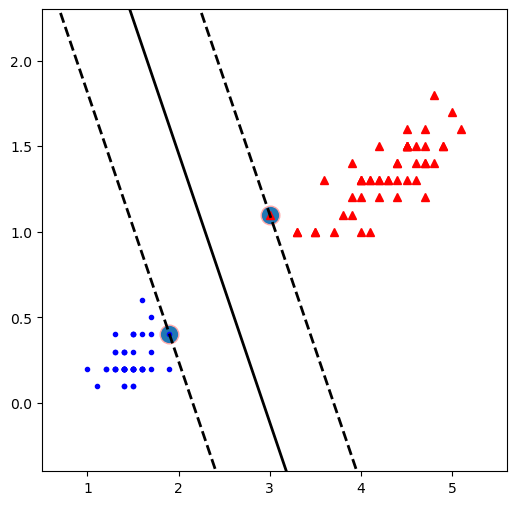

In [96]:
from matplotlib import pyplot as plt
def plot_svm_decision_boundary(svm_clf, X, sv=True):
    w = svm_clf.coef_[0]
    b = svm_clf.intercept_[0]
    xmin, xmax = X[:, 0].min() - .5, X[:, 0].max() + .5
    ymin, ymax = X[:, 1].min() - .5, X[:, 1].max() + .5
    x0 = np.linspace(xmin, xmax, 200)
    decision_boundary = -w[0]/w[1]*x0 -b/w[1]
    margin=1/w[1]
    gutter_up = decision_boundary + margin
    gutter_down = decision_boundary - margin
    if sv:
        svs = svm_clf.support_vectors_
        plt.scatter(svs[:, 0], svs[:, 1], s=180, edgecolors='#FFAAAA')

    plt.plot(x0, decision_boundary, 'k-', linewidth=2)
    plt.plot(x0, gutter_up, 'k--', linewidth=2)
    plt.plot(x0, gutter_down, 'k--', linewidth=2)
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)


def plot_svc_decision_boundary(svm_clf, X, y):
    xmin, xmax = X[:, 0].min(), X[:, 0].max()
    xx0 = np.linspace(xmin, xmax, 200)
    ## x1*w1 + x0*w0 + b = 0
    ## x1 = -(x0*w0+b)/w1
    w0 = svm_clf.coef_[0, 0]
    w1 = svm_clf.coef_[0, 1]
    b = svm_clf.intercept_

    xx1 = -1 * (w0*xx0 + b) / w1

    # norm_w = np.linalg.norm(svm_clf.coef_)
    # margin_offset_x = svm_clf.coef_[0, 0] / (norm_w ** 2)
    # margin_offset_y = svm_clf.coef_[0, 1] / (norm_w ** 2)

    ## 这里的margin是w0*x0 + w1*x1 + b = 1
    margin = 1/w1
    right = xx1 + margin
    left = xx1 - margin

    ## 使用支持向量,计算b 把b=-(w0*x0 + w1*x1)
    b1 =-1 *(svm_clf.support_vectors_[0, 0]*w0 + svm_clf.support_vectors_[0, 1]*w1)
    b2 =-1 *(svm_clf.support_vectors_[1, 0]*w0 + svm_clf.support_vectors_[1, 1]*w1)

    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "b.")
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "r^")
    plt.plot(xx0, xx1, "k", label="svm")
    plt.plot(xx0, right, "k--", label="right")
    plt.plot(xx0, left, "k--", label="left")
    # plt.plot(xx0, (1 - b - w0*xx0)/w1, "y--", label="vector right", alpha=0.5, linewidth=2)
    # plt.plot(xx0, (-1 -b - w0*xx0)/w1, "y--", label="vector left", alpha=0.5, linewidth=2)

    plt.plot(xx0, (-1* b1 - w0*xx0)/w1, "y--", label="vector right", alpha=0.5, linewidth=2)
    plt.plot(xx0, (-1* b2 - w0*xx0)/w1, "y--", label="vector left", alpha=0.5, linewidth=2)
    plt.legend()

    plt.xlim(1, 5)
    plt.ylim(-0, 2)

plt.figure(figsize=(6, 6))
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "b.")
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "r^")
plot_svm_decision_boundary(svc_clf, X)

## 绘制svm的边界曲线
### 1.可以直接画 w0*x0 + w1*x1 + b = 1或-1 这两条直线
### 2.可以先画 w0*x0 + w1*x1 + b = 0, 将x1坐标都计算出来,然后边界线就是x1加上或减去margin=1/w1,
###   x1=(-b-w0*x0)/w1
###   x11=(1-b-w0*x0)/w1,
###   它们的差距就是 1/w1
### 3.可以画通过支持向量的线,斜率即w
### 总结:1,2这两种都是使用最小距离1作为边界的,3这种是根据实际的点+线方式绘制的

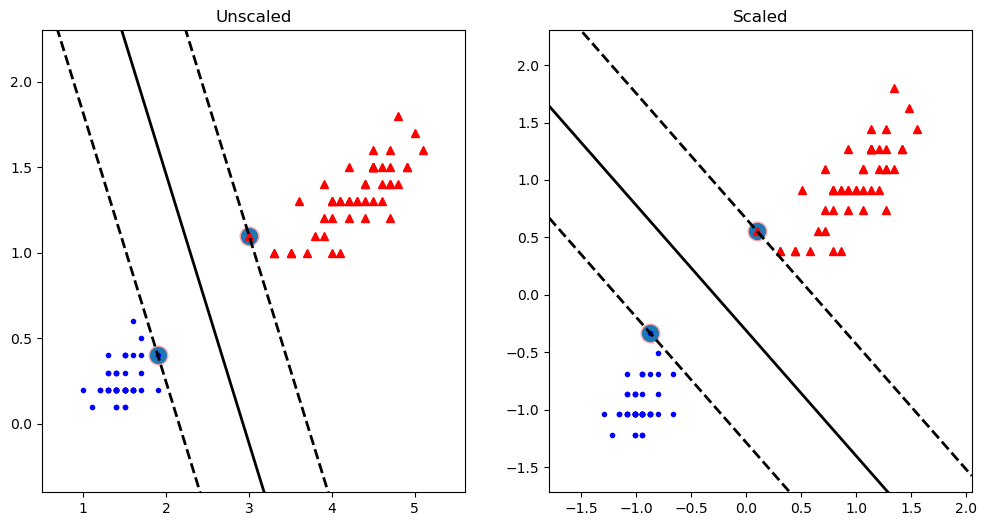

In [97]:
### 数据标准化的影响
from sklearn.preprocessing import StandardScaler
std = StandardScaler()
X_new = std.fit_transform(X)
svm_clf_new = SVC(kernel="linear", C=float('inf'))
svm_clf_new.fit(X_new, y)
svm_clf = SVC(kernel="linear", C=float('inf'))
svm_clf.fit(X, y)

plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.title("Unscaled")
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "b.")
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "r^")
plot_svm_decision_boundary(svm_clf, X)
plt.subplot(122)
plt.title("Scaled")
plt.plot(X_new[:, 0][y==0], X_new[:, 1][y==0], "b.")
plt.plot(X_new[:, 0][y==1], X_new[:, 1][y==1], "r^")
plot_svm_decision_boundary(svm_clf_new, X_new)

### 软间隔

- C越大,则拟合程度越高,容易过拟合
- C越小,则拟合程度越松,不容易过拟合

In [99]:
from sklearn.datasets import load_iris
X, y = load_iris(return_X_y=True)
X = X[:, [2, 3]]
y = (y==2).astype(np.float64)

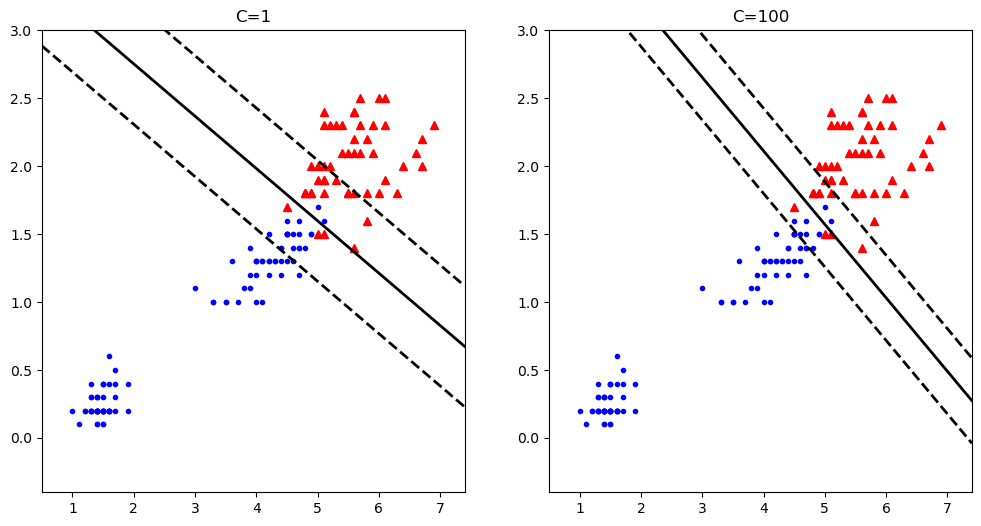

In [119]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC, LinearSVC
std = StandardScaler()
std_100 = StandardScaler()
svm_clf = LinearSVC(C=1, random_state=42)
svm_clf_100 = LinearSVC(C=100, random_state=42)
pipeline = Pipeline(
    [
        ('std', std),
        ('svc', svm_clf)
    ]
)

pipeline_100 = Pipeline(
    [
        ('std', std_100),
        ('svc', svm_clf_100)
    ]
)

pipeline.fit(X, y)
pipeline_100.fit(X, y)

## 数据还原 这里充分利用决策方程 f=x*w + b -- 原理如下的介绍
b1 = svm_clf.decision_function([-std.mean_ / std.scale_])
b2 = svm_clf_100.decision_function([-std_100.mean_ / std_100.scale_])
w1 = svm_clf.coef_[0] / std.scale_
w2 = svm_clf_100.coef_[0] / std_100.scale_
svm_clf.intercept_ = np.array([b1])
svm_clf.coef_ = np.array([w1])
svm_clf_100.intercept_ = np.array([b2])
svm_clf_100.coef_ = np.array([w2])

fig = plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.title("C=1")
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "b.")
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "r^")
plot_svm_decision_boundary(svm_clf, X, sv=False)
plt.subplot(122)
plt.title("C=100")
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "b.")
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "r^")
plot_svm_decision_boundary(svm_clf_100, X, sv=False)
plt.show()


### 数学推导：StandardScaler 对线性模型参数的影响

假设原始特征向量为 $x\_{orig}$，标准化后的特征向量为 $x\_{scaled}$。
`StandardScaler` 的变换公式是：
$$x_{scaled} = \frac{x_{orig} - \mu}{\sigma}$$
其中 $\\mu$ 是每个特征的均值（`std.mean_`），$\\sigma$ 是每个特征的标准差（`std.scale_`）。

对于一个线性 SVM（或任何线性模型），在**标准化空间**中的决策函数是：
$$f(x_{scaled}) = w_{scaled} \cdot x_{scaled} + b_{scaled}$$
其中 $w\_{scaled}$ 是在标准化数据上训练得到的权重向量（`svm_clf.coef_[0]`），$b\_{scaled}$ 是对应的截距（`svm_clf.intercept_[0]`）。

现在，我们想把这个决策函数转换成**原始数据空间**的形式：
$$f(x_{orig}) = w_{orig} \cdot x_{orig} + b_{orig}$$

我们将 $x\_{scaled}$ 的表达式代入标准化空间的决策函数：
$$w_{scaled} \cdot \left(\frac{x_{orig} - \mu}{\sigma}\right) + b_{scaled} = w_{scaled} \cdot \left(\frac{x_{orig}}{\sigma} - \frac{\mu}{\sigma}\right) + b_{scaled}$$
$$= \sum_j \left(w_{scaled,j} \frac{x_{orig,j}}{\sigma_j}\right) - \sum_j \left(w_{scaled,j} \frac{\mu_j}{\sigma_j}\right) + b_{scaled}$$

将上式重新组织成 $w\_{orig} \\cdot x\_{orig} + b\_{orig}$ 的形式：
$$= \left(\sum_j \frac{w_{scaled,j}}{\sigma_j} x_{orig,j}\right) + \left(b_{scaled} - \sum_j \frac{w_{scaled,j} \mu_j}{\sigma_j}\right)$$

通过对比，我们可以得到原始数据空间中的权重和截距：

1.  **还原后的权重 ($w\_{orig}$):**
    $$w_{orig,j} = \frac{w_{scaled,j}}{\sigma_j}$$
    这意味着每个特征的原始权重是其标准化权重除以其原始标准差。
    在代码中就是：`w_orig = svm_clf.coef_[0] / std.scale_` (您的代码中这一行是正确的)。

2.  **还原后的截距 ($b\_{orig}$):**
    $$b_{orig} = b_{scaled} - \sum_j \frac{w_{scaled,j} \mu_j}{\sigma_j}$$
    或者更简洁的向量形式：
    $$b_{orig} = b_{scaled} - w_{scaled} \cdot \left(\frac{\mu}{\sigma}\right)$$
    （注意这里的 $\\frac{\\mu}{\\sigma}$ 是元素级的除法）
    在代码中就是：`b_orig = svm_clf.intercept_[0] - np.sum(svm_clf.coef_[0] * std.mean_ / std.scale_)`。

-----

### 您的代码中的问题分析

您的代码片段：

```python
b1 = svm_clf.decision_function([-std.mean_ / std.scale_])
# ...
svm_clf.intercept_ = np.array([b1])
```

1.  **`[-std.mean_ / std.scale_]`：** 这部分是在尝试构建一个特殊的输入点，它的每个特征值都是 $-\\mu\_j / \\sigma\_j$。这个点的含义是：当原始输入 $x\_{orig}$ 为 $\\mu$ 时，对应的标准化输入 $x\_{scaled}$ 是 $( \\mu - \\mu ) / \\sigma = 0$。而当原始输入 $x\_{orig}$ 为 $0$ 时，对应的标准化输入 $x\_{scaled}$ 是 $( 0 - \\mu ) / \\sigma = -\\mu / \\sigma$。所以 `[-std.mean_ / std.scale_]` 代表的是**原始数据为零向量时，经过标准化后的数据点**。
2.  **`svm_clf.decision_function(...)`：** 当您传入 `[-std.mean_ / std.scale_]` 给 `decision_function` 时，它计算的是：
    $$f\left(-\frac{\mu}{\sigma}\right) = w_{scaled} \cdot \left(-\frac{\mu}{\sigma}\right) + b_{scaled}$$
    这与我们推导出的 $b\_{orig} = b\_{scaled} - w\_{scaled} \\cdot \\left(\\frac{\\mu}{\\sigma}\\right)$ 是**完全一致**的！

**所以，令人惊讶的是，您计算 `b1` 和 `b2` 的方式，从数学上讲，正是正确的原始截距的计算方式。** 这是一种非常巧妙的写法。

**那为什么我之前说“通常不适用”或者“需要更严谨的推导”呢？**
是因为这种写法不那么直观，对于不熟悉 `decision_function` 内部机制的人来说，它的数学推导过程隐藏在了一次函数调用中。直接按照 $b\_{orig} = b\_{scaled} - \\sum\_j \\frac{w\_{scaled,j} \\mu\_j}{\\sigma\_j}$ 来写，虽然更长，但数学含义更清晰。

-----

### 修正和完善您的代码

您的代码的核心逻辑是正确的，但为了清晰和健壮性，我们可以做一些小改进。

```python
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC # 确保导入了 LinearSVC

# 假设 X 和 y 已经定义
# X = ...
# y = ...

# ----------------- 您的原始训练代码 -----------------
std = StandardScaler()
std_100 = StandardScaler()
svm_clf = LinearSVC(C=1, random_state=42, dual=False) # dual=False 避免过拟合警告，且对于L1/L2正则化是标准做法
svm_clf_100 = LinearSVC(C=100, random_state=42, dual=False)

pipeline = Pipeline(
    [
        ('std', std),
        ('svc', svm_clf) # 注意这里是 svc，不是 clf
    ]
)

pipeline_100 = Pipeline(
    [
        ('std', std_100),
        ('svc', svm_clf_100) # 注意这里是 svc，不是 clf
    ]
)

pipeline.fit(X, y)
pipeline_100.fit(X, y)

# ----------------- 数据还原 -----------------

# 获取训练后的 StandardScaler 实例和 LinearSVC 实例
# 从 pipeline 中获取拟合后的 scaler 和 svc
fitted_std = pipeline.named_steps['std']
fitted_svm_clf = pipeline.named_steps['svc']

fitted_std_100 = pipeline_100.named_steps['std']
fitted_svm_clf_100 = pipeline_100.named_steps['svc']


# 还原 pipeline (C=1) 的参数
# 还原权重
w1_original_space = fitted_svm_clf.coef_[0] / fitted_std.scale_

# 还原截距
# 方法1: 使用您原来的巧妙方法 (数学上是正确的)
b1_original_space_method1 = fitted_svm_clf.decision_function([-fitted_std.mean_ / fitted_std.scale_])[0]

# 方法2: 显式地按照推导公式计算 (更直观的数学表达)
b1_original_space_method2 = fitted_svm_clf.intercept_[0] - np.sum(fitted_svm_clf.coef_[0] * fitted_std.mean_ / fitted_std.scale_)

# 由于 LinearSVC 的 intercept_ 属性本身就是 numpy 数组，且通常是一个单元素数组
# 在赋值时，我们可能需要确保维度匹配。
fitted_svm_clf.intercept_ = np.array([b1_original_space_method1]) # 或者 b1_original_space_method2
fitted_svm_clf.coef_ = np.array([w1_original_space]) # coef_ 也是二维数组，所以包裹一层

print(f"Pipeline (C=1) 原始空间权重 w1: {fitted_svm_clf.coef_}")
print(f"Pipeline (C=1) 原始空间截距 b1: {fitted_svm_clf.intercept_}")
print(f"验证截距计算方法一致性: {np.isclose(b1_original_space_method1, b1_original_space_method2)}")


# 还原 pipeline_100 (C=100) 的参数
w2_original_space = fitted_svm_clf_100.coef_[0] / fitted_std_100.scale_
b2_original_space_method1 = fitted_svm_clf_100.decision_function([-fitted_std_100.mean_ / fitted_std_100.scale_])[0]
b2_original_space_method2 = fitted_svm_clf_100.intercept_[0] - np.sum(fitted_svm_clf_100.coef_[0] * fitted_std_100.mean_ / fitted_std_100.scale_)

fitted_svm_clf_100.intercept_ = np.array([b2_original_space_method1])
fitted_svm_clf_100.coef_ = np.array([w2_original_space])

print(f"\nPipeline (C=100) 原始空间权重 w2: {fitted_svm_clf_100.coef_}")
print(f"Pipeline (C=100) 原始空间截距 b2: {fitted_svm_clf_100.intercept_}")
print(f"验证截距计算方法一致性: {np.isclose(b2_original_space_method1, b2_original_space_method2)}")

# 注意：
# 在实际使用中，如果你只是想用这个模型在原始数据上做预测，
# 你可以直接使用 pipeline.predict(X_original) 或 pipeline.decision_function(X_original)。
# pipeline 会自动处理内部的标准化步骤。
# 只有当你需要抽取并**解释**原始空间中的 w 和 b 时，才需要进行这种还原。
```

**关键修正和说明：**

1.  **获取拟合后的对象：** 在管道中，`std` 和 `svm_clf`（以及 `std_100` 和 `svm_clf_100`）在 `pipeline.fit()` 调用后，其内部状态（例如 `mean_`、`scale_`、`coef_`、`intercept_`）才会被更新。你应该通过 `pipeline.named_steps['std']` 和 `pipeline.named_steps['svc']` 来获取**拟合后的** `StandardScaler` 和 `LinearSVC` 实例，确保你使用的是训练后的参数。您的原始代码中直接使用了 `std` 和 `svm_clf` 变量，这取决于它们在 `fit` 之后是否被管道的内部机制自动更新。通常，`pipeline.named_steps` 是更安全的做法。
2.  **`dual=False`：** 对于 `LinearSVC`，如果特征数量远大于样本数量，或者使用 L1 惩罚，将 `dual` 设置为 `False` 通常会更快且避免警告。
3.  **截距 `intercept_` 的维度：** `svm_clf.intercept_` 是一个 NumPy 数组（通常是 `(1,)` 或 `(n_classes - 1,)`）。当您给它赋值时，最好保持其维度一致，例如 `np.array([b1])`。
4.  **系数 `coef_` 的维度：** `svm_clf.coef_` 也是一个 NumPy 数组（对于二分类通常是 `(1, n_features)`）。所以赋值时也应该保持其形状，例如 `np.array([w1])`。

通过上述分析，您的还原逻辑在数学上是正确的，并且 `decision_function` 的巧妙使用确实简化了截距的计算表达式。

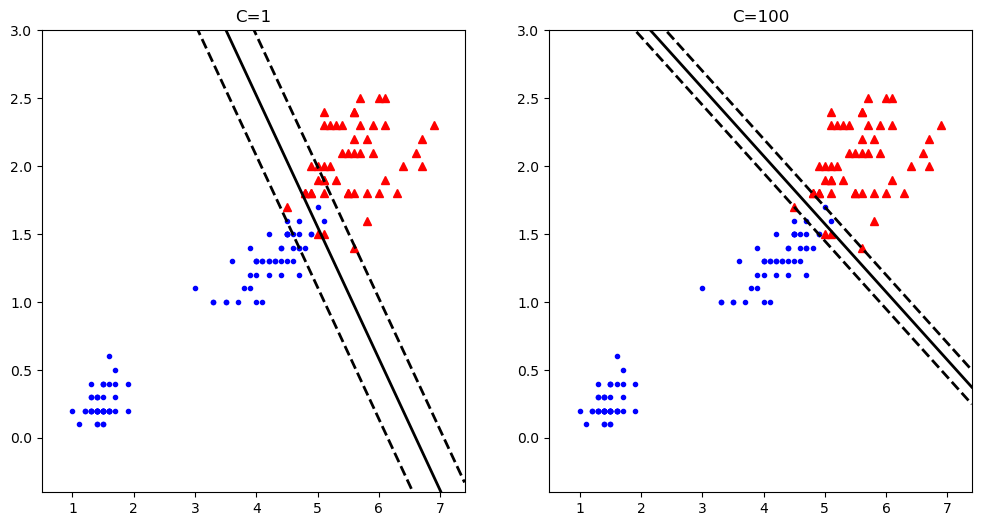

In [117]:
svm_clf = SVC(kernel="linear", C=1)
svm_clf.fit(X, y)
svm_clf_100 = SVC(kernel="linear", C=100)
svm_clf_100.fit(X, y)

fig = plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.title("C=1")
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "b.")
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "r^")
plot_svm_decision_boundary(svm_clf, X, sv=False)
plt.subplot(122)
plt.title("C=100")
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "b.")
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "r^")
plot_svm_decision_boundary(svm_clf_100, X, sv=False)
plt.show()

In [116]:
## decision_function 是 SVM 中非常核心的一个函数，表示样本点到分割超平面的“有符号距离”，在分类、绘图、排序等任务中都有重要用途。
svm_clf.decision_function(X)

array([-10.90804252, -10.90804252, -11.12633499, -10.68975005,
       -10.90804252,  -9.80243393, -10.68267693, -10.68975005,
       -10.90804252, -10.91511563, -10.68975005, -10.47145758,
       -11.1334081 , -11.78828552, -11.34462746, -10.23901887,
       -10.67560381, -10.68267693, -10.02779952, -10.46438446,
       -10.25316511, -10.23901887, -11.7812124 ,  -9.57706834,
        -9.81658016, -10.47145758, -10.0207264 , -10.68975005,
       -10.90804252, -10.47145758, -10.47145758, -10.23901887,
       -10.91511563, -10.90804252, -10.68975005, -11.34462746,
       -11.12633499, -11.1334081 , -11.12633499, -10.68975005,
       -10.9009694 , -10.9009694 , -11.12633499,  -9.56999522,
        -9.36584899, -10.68267693, -10.47145758, -10.90804252,
       -10.68975005, -10.90804252,  -1.00000394,  -1.21122329,
        -0.33805341,  -2.75341682,  -0.99293082,  -1.66195447,
        -0.54927276,  -4.95756088,  -1.443662  ,  -2.7463437 ,
        -4.52097594,  -1.8661007 ,  -3.42951358,  -1.00

## 非线性支持向量机